In [34]:
from pathlib import Path
example_data_path = Path("../../parcels_example_data/")

import parcels

from matplotlib import pyplot as plt
import cartopy

import xarray as xr
import numpy as np

import datetime

In [2]:
GlobCurrent_example_data_path = example_data_path / "GlobCurrent_example_data"

filenames = {
    "U": GlobCurrent_example_data_path / "20*.nc",
    "V": GlobCurrent_example_data_path / "20*.nc",
}

variables = {
    "U": "eastward_eulerian_current_velocity",
    "V": "northward_eulerian_current_velocity",
}
dimensions = {"lat": "lat", "lon": "lon", "time": "time"}

fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions, deferred_load=False)

## Create ParticleSets

In [ ]:
number_particles = 1_000 # per location
lon_bds = np.min(fieldset.U.grid.lon), np.max(fieldset.U.grid.lon)
lat_bds = np.min(fieldset.U.grid.lat), np.max(fieldset.U.grid.lat)
#lon_bds = (24, 27)
#lat_bds = (-39, -34.5)
time_0 = fieldset.U.grid.time[0]

In [ ]:
lon_bds1 = (25)
lat_bds1 = (-36)

lon_bds2 = (20) 
lat_bds2 = (-35.5)

lon_bds3 = (32)
lat_bds3 = (-37.5)

lon_bds4 = (16)
lat_bds4 = (-31.5)

lon_bds5 = (31)
lat_bds5 = (-34.5)

lon_bds6 = (17.5)
lat_bds6 = (-37.5)
# Centers of release areas with
radius = 0.05 # degree

Particles are uniformly distributed inside a circle

In [45]:
r = radius * np.sqrt(np.random.uniform(size=(number_particles)))
theta = np.random.uniform(size=(number_particles)) * 2 * np.pi
# (x – xM)² + (y – yM)² = r²
#x = lon_bds + r * np.cos(theta)
#y = lat_bds + r * np.sin(theta)
time_0 = fieldset.U.grid.time[-1]

31536000.0

In [ ]:
particleset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=np.random.uniform(*lon_bds, size=(number_particles, )),
    lat=np.random.uniform(*lat_bds, size=(number_particles, )),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [5]:
pset1 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds1 + r * np.cos(theta),
    lat= lat_bds1 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [6]:
pset2 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds2 + r * np.cos(theta),
    lat= lat_bds2 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [7]:
pset3 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds3 + r * np.cos(theta),
    lat= lat_bds3 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [8]:
pset4 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds4 + r * np.cos(theta),
    lat= lat_bds4 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [9]:
pset5 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds5 + r * np.cos(theta),
    lat= lat_bds5 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

In [10]:
pset6 = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon= lon_bds6 + r * np.cos(theta),
    lat= lat_bds6 + r * np.sin(theta),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

Create an error-handling kernel which deletes particles with too high status codes.

In [11]:
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

OutputFiles

In [12]:
MultipleSites1 = pset1.ParticleFile(
    name="MultipleSites1.zarr", outputdt=datetime.timedelta(hours=6)
)

In [13]:
MultipleSites2 = pset2.ParticleFile(
    name="MultipleSites2.zarr", outputdt=datetime.timedelta(hours=6)
)

In [14]:
MultipleSites3 = pset3.ParticleFile(
    name="MultipleSites3.zarr", outputdt=datetime.timedelta(hours=6)
)

In [15]:
MultipleSites4 = pset4.ParticleFile(
    name="MultipleSites4.zarr", outputdt=datetime.timedelta(hours=6)
)

In [16]:
MultipleSites5 = pset5.ParticleFile(
    name="MultipleSites5.zarr", outputdt=datetime.timedelta(hours=6)
)

In [17]:
MultipleSites6 = pset6.ParticleFile(
    name="MultipleSites6.zarr", outputdt=datetime.timedelta(hours=6)
)

Execute the `ParticleSet` for 10 days at 5-minute time step using the 4th order Runge-Kutta kernel and the Error Kernel above.
Capture output every 6 hours.

In [ ]:
output_file = particleset.ParticleFile(
    name="Experiment1.zarr", outputdt=datetime.timedelta(hours=6)
)
particleset.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=10),
    dt=datetime.timedelta(minutes=5),
    output_file=output_file,
)

In [18]:
pset1.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites1,
)

INFO: Output files are stored in MultipleSites1.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 166993.56it/s]


In [19]:
pset2.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites2,
)

INFO: Output files are stored in MultipleSites2.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 167026.48it/s]


In [20]:
pset3.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites3,
)

INFO: Output files are stored in MultipleSites3.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 165341.55it/s]


In [21]:
pset4.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites4,
)

INFO: Output files are stored in MultipleSites4.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 167653.20it/s]


In [22]:
pset5.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites5,
)

INFO: Output files are stored in MultipleSites5.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 166729.83it/s]


In [23]:
pset6.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30),
    dt=-datetime.timedelta(minutes=10),
    output_file=MultipleSites6,
)

INFO: Output files are stored in MultipleSites6.zarr.
100%|██████████| 2592000.0/2592000.0 [00:15<00:00, 167160.15it/s]


## Have a look at the output

In [ ]:
ds = xr.open_zarr("Experiment1.zarr").compute()

In [24]:
ds1 = xr.open_zarr("MultipleSites1.zarr").compute()

In [25]:
ds2 = xr.open_zarr("MultipleSites2.zarr").compute()

In [26]:
ds3 = xr.open_zarr("MultipleSites3.zarr").compute()
#ds

In [27]:
ds4 = xr.open_zarr("MultipleSites4.zarr").compute()

In [28]:
ds5 = xr.open_zarr("MultipleSites5.zarr").compute()

In [29]:
ds6 = xr.open_zarr("MultipleSites6.zarr").compute()

## Plot trajectories

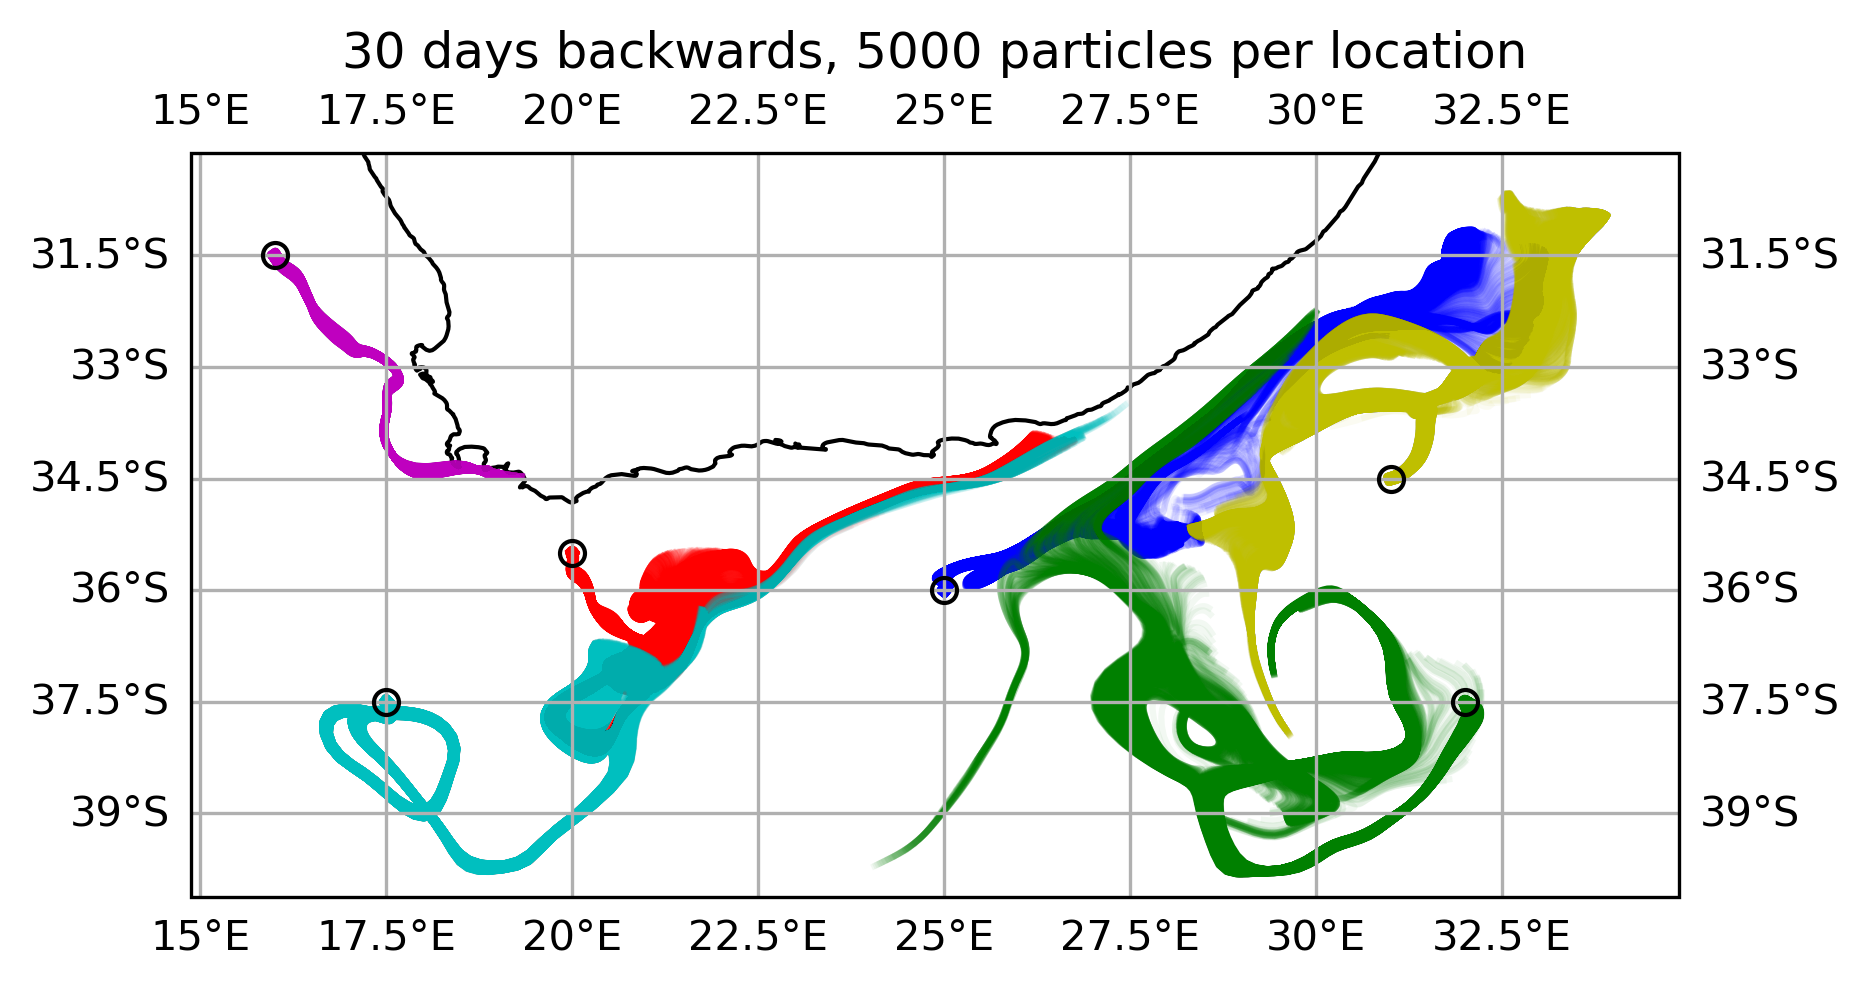

In [55]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": cartopy.crs.PlateCarree()})
fig.set_dpi(250)
for n in range(ds1.sizes["trajectory"]):
    ax.plot(
        *ds1.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="b", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

for n in range(ds2.sizes["trajectory"]):
    ax.plot(
        *ds2.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="r", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

for n in range(ds3.sizes["trajectory"]):
    ax.plot(
        *ds3.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

for n in range(ds4.sizes["trajectory"]):
    ax.plot(
        *ds4.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="m", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

for n in range(ds5.sizes["trajectory"]):
    ax.plot(
        *ds5.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="y", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

for n in range(ds6.sizes["trajectory"]):
    ax.plot(
        *ds6.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="c", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )
ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    np.min(fieldset.U.grid.lat),
    np.max(fieldset.U.grid.lat),
])
ax.gridlines(draw_labels=True);
plt.plot((lon_bds1,lon_bds2,lon_bds3,lon_bds4,lon_bds5,lon_bds6),(lat_bds1,lat_bds2,lat_bds3,lat_bds4,lat_bds5,lat_bds6), "ko",fillstyle="none")
plt.title("30 days backwards, 5000 particles per location")
plt.savefig('30Days6Locations5000.png')